In [16]:
# Phan 3
# thu vien dung cho phan 3 nay
import numpy as np
import pandas as pd
# them doan nay de in ra khong con hien e+07
pd.set_option("display.float_format", lambda x: "{:,.2f}".format(x))
# Phan 3.1
# Set random seed de ket qua co the tai lap lai
np.random.seed(2026)
so_don_hang = 350
# Tao cac danh sach gia tri mau
ds_kenh = ["Shopee", "Lazada", "Tiki", "Website", "Cua hang"]
ds_trang_thai = ["done","done","done","shipping","cancelled"]
ds_khu_vuc = ["Ha Dong","Cau Giay","Nam Tu Liem","Thanh Tri"]
ds_danh_muc = ["Thoi trang","Dien tu","Gia dung","Me va Be"]
ma_don = []
for i in range(so_don_hang):
    ma = "DH"
    if i + 1 < 10:
        ma = ma + "000" + str(i + 1)
    elif i + 1 < 100:
        ma = ma + "00" + str(i + 1)
    else:
        ma = ma + "0" + str(i + 1)
    ma_don.append(ma)
gia_tri = np.random.randint(100000,2000000,so_don_hang)
chiet_khau = np.random.choice([0,0.05,0.1,0.15,0.2],so_don_hang)
so_luong = np.random.randint(1, 10,so_don_hang)
kenh_ban = np.random.choice(ds_kenh,so_don_hang)
trang_thai = np.random.choice(ds_trang_thai,so_don_hang)
khu_vuc = np.random.choice(ds_khu_vuc,so_don_hang)
danh_muc = np.random.choice(ds_danh_muc,so_don_hang)
ngay_dat = pd.date_range(start="2026-01-01", periods=so_don_hang)
# Tao DataFrame
df_orders = pd.DataFrame()
df_orders["ma_don"] = ma_don
df_orders["gia_tri"] = gia_tri
df_orders["chiet_khau"] = chiet_khau
df_orders["so_luong"] = so_luong
df_orders["kenh_ban"] = kenh_ban
df_orders["trang_thai"] = trang_thai
df_orders["khu_vuc"] = khu_vuc
df_orders["danh_muc"] = danh_muc
df_orders["ngay"] = ngay_dat
# Tao mot vai loi du lieu de lam sach
# Tao gia tri rong
df_orders.loc[5,"gia_tri"] = np.nan
df_orders.loc[10,"gia_tri"] = np.nan
df_orders.loc[15,"gia_tri"] = np.nan
df_orders.loc[20,"chiet_khau"] = np.nan
df_orders.loc[21,"chiet_khau"] = np.nan
# Tao trung lap
df_orders.loc[350] = df_orders.loc[0]
df_orders.loc[351] = df_orders.loc[1]
# Tao outlier
df_orders.loc[50,"gia_tri"] = 50000000
# Bao cao truoc khi lam sach
print("data truoc khi lam sach la:")
print()
print("Tong so dong:")
print(len(df_orders))
print()
print("So gia tri rong:")
print(df_orders.isnull().sum())
print()
print("So dong trung lap:")
print(df_orders.duplicated().sum())
print()
# Bat dau lam sach
# Xoa trung lap
df_clean = df_orders.drop_duplicates().copy()
# Dien gia tri thieu
gia_tri_trung_vi = df_clean["gia_tri"].median()
df_clean["gia_tri"] = df_clean["gia_tri"].fillna(gia_tri_trung_vi)
df_clean["chiet_khau"] = df_clean["chiet_khau"].fillna(0)
# Tim outlier bang IQR
Q1 = df_clean["gia_tri"].quantile(0.25)
Q3 = df_clean["gia_tri"].quantile(0.75)
IQR = Q3 - Q1
gioi_han_duoi = Q1 - IQR * 1.5
gioi_han_tren = Q3 + IQR * 1.5
# Thay outlier bang gioi han tren
df_clean.loc[df_clean["gia_tri"] > gioi_han_tren,"gia_tri"] = gioi_han_tren
# Bao cao sau khi lam sach
print("data sau khi lam sach la:")
print()
print("Tong so dong:")
print(len(df_clean))
print()
print("Tong so gia tri rong:")
print(df_clean.isnull().sum().sum())
print()
print("Tong so dong trung lap:")
print(df_clean.duplicated().sum())
print()
print("5 dong dau tien:")
print(df_clean.head())
# Luu file CSV
df_clean.to_csv("du_lieu_don_hang.csv",index=False,encoding="utf-8-sig")
print()
print("Da luu file du_lieu_don_hang.csv")

data truoc khi lam sach la:

Tong so dong:
352

So gia tri rong:
ma_don        0
gia_tri       3
chiet_khau    2
so_luong      0
kenh_ban      0
trang_thai    0
khu_vuc       0
danh_muc      0
ngay          0
dtype: int64

So dong trung lap:
2

data sau khi lam sach la:

Tong so dong:
350

Tong so gia tri rong:
0

Tong so dong trung lap:
0

5 dong dau tien:
   ma_don      gia_tri  chiet_khau  so_luong  kenh_ban trang_thai    khu_vuc  \
0  DH0001   561,057.00        0.15         6      Tiki       done  Thanh Tri   
1  DH0002   132,134.00        0.10         2    Lazada   shipping   Cau Giay   
2  DH0003 1,878,458.00        0.00         7    Shopee       done    Ha Dong   
3  DH0004 1,178,200.00        0.10         6  Cua hang       done   Cau Giay   
4  DH0005   413,421.00        0.10         1   Website  cancelled    Ha Dong   

   danh_muc       ngay  
0  Me va Be 2026-01-01  
1   Dien tu 2026-01-02  
2   Dien tu 2026-01-03  
3  Gia dung 2026-01-04  
4  Me va Be 2026-01-05  

Da luu f

In [7]:
# PHAN 3.2a
print("Thong ke mo ta cac cot so")
print()
# chon cac cot so can thong ke
du_lieu_so = df_clean[["gia_tri", "chiet_khau", "so_luong"]]
# thong ke
bang_thong_ke = du_lieu_so.describe()
print(bang_thong_ke)
print()
print("Nhan xet:")
print("Gia tri don hang co gia tri nho nhat la:",
      df_clean["gia_tri"].min())
print("Gia tri don hang lon nhat la:",
      df_clean["gia_tri"].max())
print("Gia tri trung binh la:",
      df_clean["gia_tri"].mean())
print("Chiet khau trung binh la:",
      df_clean["chiet_khau"].mean())
print("So luong san pham trung binh la:",
      df_clean["so_luong"].mean())
print()
print("Ket luan:")
print("Gia tri don hang dao dong tu muc thap den muc cao.")
print("Chiet khau chu yeu nam trong khoang 0 den 20 phan tram.")
print("So luong san pham moi don khong qua lon.")

Thong ke mo ta cac cot so

           gia_tri  chiet_khau  so_luong
count       350.00      350.00    350.00
mean    990,578.15        0.09      4.98
std     555,192.80        0.07      2.45
min     100,316.00        0.00      1.00
25%     505,476.75        0.05      3.00
50%     979,736.00        0.10      5.00
75%   1,446,459.75        0.15      7.00
max   2,857,934.25        0.20      9.00

Nhan xet:
Gia tri don hang co gia tri nho nhat la: 100316.0
Gia tri don hang lon nhat la: 2857934.25
Gia tri trung binh la: 990578.1492857143
Chiet khau trung binh la: 0.09414285714285715
So luong san pham trung binh la: 4.982857142857143

Ket luan:
Gia tri don hang dao dong tu muc thap den muc cao.
Chiet khau chu yeu nam trong khoang 0 den 20 phan tram.
So luong san pham moi don khong qua lon.


In [8]:
# Phan 3.2b
print("Thong ke theo kenh ban")
print()
# Tao them 2 cot de de tinh toan
df_clean["don_da_giao"] = 0
for i in df_clean.index:
    if df_clean.loc[i, "trang_thai"] == "da giao":
        df_clean.loc[i, "don_da_giao"] = 1
df_clean["doanh_thu_da_giao"] = 0
for i in df_clean.index:
    if df_clean.loc[i, "trang_thai"] == "da giao":
        df_clean.loc[i, "doanh_thu_da_giao"] = df_clean.loc[i, "gia_tri"]
# Nhom theo kenh ban
bang_kenh = df_clean.groupby("kenh_ban").agg(so_don=("ma_don", "count"),tong_doanh_thu=("gia_tri", "sum"),doanh_thu_trung_binh=("gia_tri", "mean"),tong_don_da_giao=("don_da_giao", "sum"),doanh_thu_done=("doanh_thu_da_giao", "sum"))
# Them cot moi
bang_kenh["ty_le_hoan_thanh"] = (bang_kenh["tong_don_da_giao"] /bang_kenh["so_don"]) * 100
bang_kenh["doanh_thu_tb_don_da_giao"] = (bang_kenh["doanh_thu_done"] /bang_kenh["tong_don_da_giao"])
# Sap xep
bang_kenh = bang_kenh.sort_values(by="tong_doanh_thu",ascending=False)
print(bang_kenh)
print()
print("Phan tich:")
kenh_max = bang_kenh.index[0]
print("Kenh co tong doanh thu cao nhat la:", kenh_max)
print("Tong doanh thu cua kenh nay la:")
print(bang_kenh.iloc[0]["tong_doanh_thu"])
print()
print("Ty le hoan thanh cua tung kenh:")
for ten in bang_kenh.index:
    print(ten, ":", round(bang_kenh.loc[ten, "ty_le_hoan_thanh"], 2), "%")

Thong ke theo kenh ban

          so_don  tong_doanh_thu  doanh_thu_trung_binh  tong_don_da_giao  \
kenh_ban                                                                   
Shopee        76   75,534,455.25            993,874.41                 0   
Cua hang      69   71,390,649.00          1,034,647.09                 0   
Website       74   70,796,543.00            956,710.04                 0   
Tiki          65   68,899,800.00          1,059,996.92                 0   
Lazada        66   60,080,905.00            910,316.74                 0   

          doanh_thu_done  ty_le_hoan_thanh  doanh_thu_tb_don_da_giao  
kenh_ban                                                              
Shopee                 0              0.00                       NaN  
Cua hang               0              0.00                       NaN  
Website                0              0.00                       NaN  
Tiki                   0              0.00                       NaN  
Lazada           

In [9]:
# Phan 3.2c
print("Phan tich xu huong doanh thu theo thoi gian")
print()
# Chi lay cac don hang da hoan thanh
df_done = df_clean[df_clean["trang_thai"] == "done"].copy()
# Tao cot thang tu cot ngay
df_done["thang"] = df_done["ngay"].dt.to_period("M")
# Tinh tong doanh thu cua tung thang
bang_thang = df_done.groupby("thang").agg(tong_doanh_thu=("gia_tri", "sum"))
# Tinh trung binh dong 3 thang lien tiep
bang_thang["rolling_3_thang"] = (bang_thang["tong_doanh_thu"].rolling(window=3).mean())
print("Bang doanh thu theo thang:")
print()
print(bang_thang)
print()
# Tim thang doanh thu cao nhat
thang_max = bang_thang["tong_doanh_thu"].idxmax()
dt_max = bang_thang["tong_doanh_thu"].max()
# Tim thang doanh thu thap nhat
thang_min = bang_thang["tong_doanh_thu"].idxmin()
dt_min = bang_thang["tong_doanh_thu"].min()
print("Thang co doanh thu cao nhat:")
print(thang_max)
print(dt_max)
print()
print("Phan tich:")
print("Thang doanh thu cao nhat la:", thang_max)
print("Thang doanh thu thap nhat la:", thang_min)
print("Gia tri Rolling Average giup de quan sat xu huong doanh thu.")

Phan tich xu huong doanh thu theo thoi gian

Bang doanh thu theo thang:

         tong_doanh_thu  rolling_3_thang
thang                                   
2026-01   20,432,686.00              NaN
2026-02   15,985,050.00              NaN
2026-03   11,008,751.00    15,808,829.00
2026-04   10,728,831.00    12,574,210.67
2026-05   22,085,193.00    14,607,591.67
2026-06   14,597,489.00    15,803,837.67
2026-07   14,848,436.00    17,177,039.33
2026-08   17,865,262.00    15,770,395.67
2026-09   15,391,432.00    16,035,043.33
2026-10   12,843,865.00    15,366,853.00
2026-11   17,051,958.00    15,095,751.67
2026-12    7,653,022.00    12,516,281.67

Thang co doanh thu cao nhat:
2026-05
22085193.0

Phan tich:
Thang doanh thu cao nhat la: 2026-05
Thang doanh thu thap nhat la: 2026-12
Gia tri Rolling Average giup de quan sat xu huong doanh thu.


In [10]:
# Phan 3.2d
print("Phan tich doanh thu theo khu vuc")
print()
bang_pivot = pd.pivot_table(df_clean,values="gia_tri",index="khu_vuc",columns="danh_muc",aggfunc="sum",fill_value=0)
print("Bang Pivot Table:")
print()
print(bang_pivot)
print()
tong_doanh_thu_khu_vuc = df_clean.groupby("khu_vuc")["gia_tri"].sum()
tong_doanh_thu = df_clean["gia_tri"].sum()
print("Ty le dong gop doanh thu cua tung khu vuc:")
print()
for ten_khu_vuc in tong_doanh_thu_khu_vuc.index:
    doanh_thu = tong_doanh_thu_khu_vuc[ten_khu_vuc]
    ty_le = doanh_thu * 100 / tong_doanh_thu
    print("Khu vuc:", ten_khu_vuc)
    print("Tong doanh thu:", doanh_thu)
    print("Ty le dong gop:", round(ty_le,2), "%")
    print()
# Tim khu vuc co doanh thu cao nhat
khu_max = tong_doanh_thu_khu_vuc.idxmax()
dt_max = tong_doanh_thu_khu_vuc.max()
print()
print("Phan tich:")
print("Khu vuc co doanh thu cao nhat la:")
print(khu_max)
print("Tong doanh thu:")
print(dt_max)
print()
print("Ty le dong gop cua tung khu vuc:")
for ten_khu_vuc in tong_doanh_thu_khu_vuc.index:
    doanh_thu = tong_doanh_thu_khu_vuc[ten_khu_vuc]
    ty_le = doanh_thu * 100 / tong_doanh_thu
    print(ten_khu_vuc, ":", round(ty_le, 2), "%")
print()
print("Moi khu vuc co muc dong gop doanh thu khac nhau.")
print("Khu vuc co doanh thu cao nhat dong gop nhieu nhat vao tong doanh thu.")

Phan tich doanh thu theo khu vuc

Bang Pivot Table:

danh_muc          Dien tu      Gia dung      Me va Be    Thoi trang
khu_vuc                                                            
Cau Giay    26,509,330.00 20,114,939.00 23,194,982.00 20,733,190.00
Ha Dong     33,798,129.00 19,080,614.00 27,717,017.00 25,623,303.00
Nam Tu Liem 21,349,742.25 22,739,829.00 24,347,265.00 15,954,081.00
Thanh Tri   17,689,478.00 16,101,823.00  9,554,750.00 22,193,880.00

Ty le dong gop doanh thu cua tung khu vuc:

Khu vuc: Cau Giay
Tong doanh thu: 90552441.0
Ty le dong gop: 26.12 %

Khu vuc: Ha Dong
Tong doanh thu: 106219063.0
Ty le dong gop: 30.64 %

Khu vuc: Nam Tu Liem
Tong doanh thu: 84390917.25
Ty le dong gop: 24.34 %

Khu vuc: Thanh Tri
Tong doanh thu: 65539931.0
Ty le dong gop: 18.9 %


Phan tich:
Khu vuc co doanh thu cao nhat la:
Ha Dong
Tong doanh thu:
106219063.0

Ty le dong gop cua tung khu vuc:
Cau Giay : 26.12 %
Ha Dong : 30.64 %
Nam Tu Liem : 24.34 %
Thanh Tri : 18.9 %

Moi khu vuc co 

In [11]:
# Phan 3.2e
print("Phan tich tuong quan Pearson")
print()
bang_tuong_quan = df_clean[["gia_tri", "chiet_khau", "so_luong"]].corr(method="pearson")
print("Ma tran tuong quan:")
print()
print(bang_tuong_quan)
print()
gt_sl = bang_tuong_quan.loc["gia_tri", "so_luong"]
gt_ck = bang_tuong_quan.loc["gia_tri", "chiet_khau"]
sl_ck = bang_tuong_quan.loc["so_luong", "chiet_khau"]
print("Nhan xet:")
print()
print("Gia tri va so luong:")
print(gt_sl)
if abs(gt_sl) < 0.3:
    print("Moi tuong quan yeu.")
elif abs(gt_sl) < 0.7:
    print("Moi tuong quan trung binh.")
else:
    print("Moi tuong quan manh.")
if gt_sl > 0:
    print("Hai bien bien dong cung chieu.")
else:
    print("Hai bien bien dong nguoc chieu.")
print()
print("Gia tri va chiet khau:")
print(gt_ck)
if abs(gt_ck) < 0.3:
    print("Moi tuong quan yeu.")
elif abs(gt_ck) < 0.7:
    print("Moi tuong quan trung binh.")
else:
    print("Moi tuong quan manh.")
if gt_ck > 0:
    print("Hai bien bien dong cung chieu.")
else:
    print("Hai bien bien dong nguoc chieu.")
print()
print("So luong va chiet khau:")
print(sl_ck)
if abs(sl_ck) < 0.3:
    print("Moi tuong quan yeu.")
elif abs(sl_ck) < 0.7:
    print("Moi tuong quan trung binh.")
else:
    print("Moi tuong quan manh.")
if sl_ck > 0:
    print("Hai bien bien dong cung chieu.")
else:
    print("Hai bien bien dong nguoc chieu.")

Phan tich tuong quan Pearson

Ma tran tuong quan:

            gia_tri  chiet_khau  so_luong
gia_tri        1.00        0.03      0.00
chiet_khau     0.03        1.00      0.02
so_luong       0.00        0.02      1.00

Nhan xet:

Gia tri va so luong:
0.004043561909288653
Moi tuong quan yeu.
Hai bien bien dong cung chieu.

Gia tri va chiet khau:
0.02577470688106996
Moi tuong quan yeu.
Hai bien bien dong cung chieu.

So luong va chiet khau:
0.015772443302049226
Moi tuong quan yeu.
Hai bien bien dong cung chieu.


In [12]:
# PHAN 3.3
print("Phan tich NumPy truc tiep")
print()
# Chuyen 2 cot tu DataFrame sang mang NumPy
mang_gia_tri = df_clean["gia_tri"].to_numpy()
mang_chiet_khau = df_clean["chiet_khau"].to_numpy()
# a
print("doanh thu sau chiet khau")
print()
doanh_thu_sau_chiet_khau = mang_gia_tri * (1 - mang_chiet_khau)
print("10 gia tri dau tien:")
print(doanh_thu_sau_chiet_khau[:10])
print()
# b
print("Phan loai don hang")
phan_loai_don_hang = np.where(mang_gia_tri >= 1000000,"Don lon","Don thuong")
print()
print("10 don dau tien sau khi phan loai:")
print(phan_loai_don_hang[:10])
print()
# c
print("Tim phan vi va dem outlier")
Q1 = np.percentile(mang_gia_tri,25)
Q2 = np.percentile(mang_gia_tri,50)
Q3 = np.percentile(mang_gia_tri,75)
IQR = Q3 - Q1
gioi_han_duoi = Q1 - 1.5 * IQR
gioi_han_tren = Q3 + 1.5 * IQR
mang_outlier = mang_gia_tri[(mang_gia_tri < gioi_han_duoi) |(mang_gia_tri > gioi_han_tren)]
print()
print("Phan vi 25:")
print(Q1)
print()
print("Phan vi 50:")
print(Q2)
print()
print("Phan vi 75:")
print(Q3)
print()
print("So luong outlier:")
print(len(mang_outlier))
print()
print("Cac gia tri outlier:")
print(mang_outlier)

Phan tich NumPy truc tiep

doanh thu sau chiet khau

10 gia tri dau tien:
[ 476898.45  118920.6  1878458.   1060380.    372078.9   930749.2
  103467.6  1062550.4   879699.    982381.55]

Phan loai don hang

10 don dau tien sau khi phan loai:
['Don thuong' 'Don thuong' 'Don lon' 'Don lon' 'Don thuong' 'Don thuong'
 'Don thuong' 'Don lon' 'Don thuong' 'Don lon']

Tim phan vi va dem outlier

Phan vi 25:
505476.75

Phan vi 50:
979736.0

Phan vi 75:
1446459.75

So luong outlier:
0

Cac gia tri outlier:
[]


Dang ve dashboard...


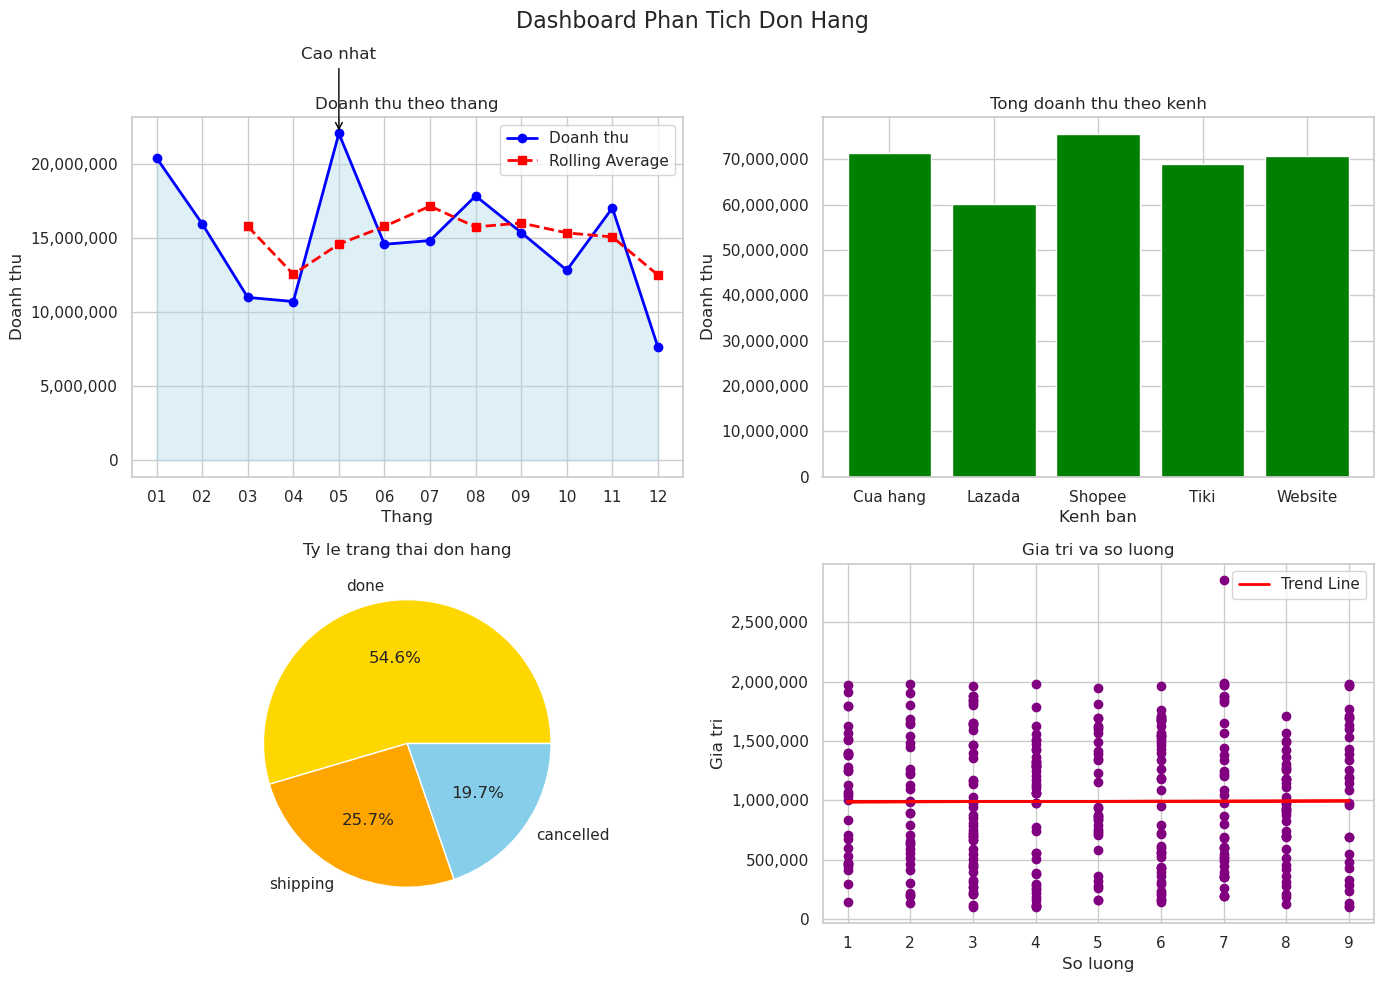


Da luu file dashboard_matplotlib.png


In [13]:
# PHAN 4.1
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import StrMethodFormatter
print("Dang ve dashboard...")
# Tao Figure
fig = plt.figure(figsize=(14,10))
# Chia man hinh thanh 2 hang 2 cot
grid = fig.add_gridspec(2,2)
# BIEU DO 1 - XU HUONG DOANH THU THEO THANG
ax1 = fig.add_subplot(grid[0,0])
# Lay cac don hang da giao
bang_doanh_thu = df_clean[df_clean["trang_thai"] == "done"].copy()
# Tao cot thang
bang_doanh_thu["thang"] = bang_doanh_thu["ngay"].dt.to_period("M")
# Tong doanh thu tung thang
tong_theo_thang = bang_doanh_thu.groupby("thang")["gia_tri"].sum()
# Rolling Average 3 thang
rolling = tong_theo_thang.rolling(3).mean()
# Tao truc x
x = range(len(tong_theo_thang))
# Ve doanh thu
ax1.plot(x,tong_theo_thang.values,color="blue",linewidth=2,marker="o",label="Doanh thu")
# Ve Rolling Average
ax1.plot(x,rolling.values,color="red",linewidth=2,linestyle="--",marker="s",label="Rolling Average")
# To mau
ax1.fill_between(x,tong_theo_thang.values,color="lightblue",alpha=0.4)
# Tim diem cao nhat
vi_tri_max = np.argmax(tong_theo_thang.values)
ax1.annotate("Cao nhat",xy=(vi_tri_max, tong_theo_thang.values[vi_tri_max]),xytext=(vi_tri_max,tong_theo_thang.values[vi_tri_max] + 5000000),ha="center",arrowprops=dict(arrowstyle="->",color="black"))
# Ten thang
nhan_thang = []
for thang in tong_theo_thang.index:
    nhan_thang.append(thang.strftime("%m"))
ax1.set_xticks(list(x))
ax1.set_xticklabels(nhan_thang)
ax1.set_title("Doanh thu theo thang")
ax1.set_xlabel("Thang")
ax1.set_ylabel("Doanh thu")
# Khong hien 1e7
ax1.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax1.legend()
# BIEU DO 2 - BAR CHART
ax2 = fig.add_subplot(grid[0,1])
tong_kenh = df_clean.groupby("kenh_ban")["gia_tri"].sum()
ax2.bar(tong_kenh.index,tong_kenh.values,color="green")
ax2.set_title("Tong doanh thu theo kenh")
ax2.set_xlabel("Kenh ban")
ax2.set_ylabel("Doanh thu")
ax2.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
# BIEU DO 3 - PIE CHART
ax3 = fig.add_subplot(grid[1,0])
dem_trang_thai = df_clean["trang_thai"].value_counts()
ax3.pie(dem_trang_thai.values,labels=dem_trang_thai.index,autopct="%1.1f%%",colors=["gold","orange","skyblue"])
ax3.set_title("Ty le trang thai don hang")
# BIEU DO 4 - SCATTER
ax4 = fig.add_subplot(grid[1,1])
x = df_clean["so_luong"]
y = df_clean["gia_tri"]
ax4.scatter(x,y,color="purple")
# Ve duong xu huong
he_so = np.polyfit(x,y,1)
duong = np.poly1d(he_so)
ax4.plot(x,duong(x),color="red",linewidth=2,label="Trend Line")
ax4.set_title("Gia tri va so luong")
ax4.set_xlabel("So luong")
ax4.set_ylabel("Gia tri")
ax4.yaxis.set_major_formatter(StrMethodFormatter("{x:,.0f}"))
ax4.legend()
# TIEU DE CHUNG
fig.suptitle("Dashboard Phan Tich Don Hang",fontsize=16)
plt.tight_layout()
plt.savefig(
    "dashboard_matplotlib.png",
    dpi=200
)
plt.show()
print()
print("Da luu file dashboard_matplotlib.png")

Dang ve dashboard seaborn...



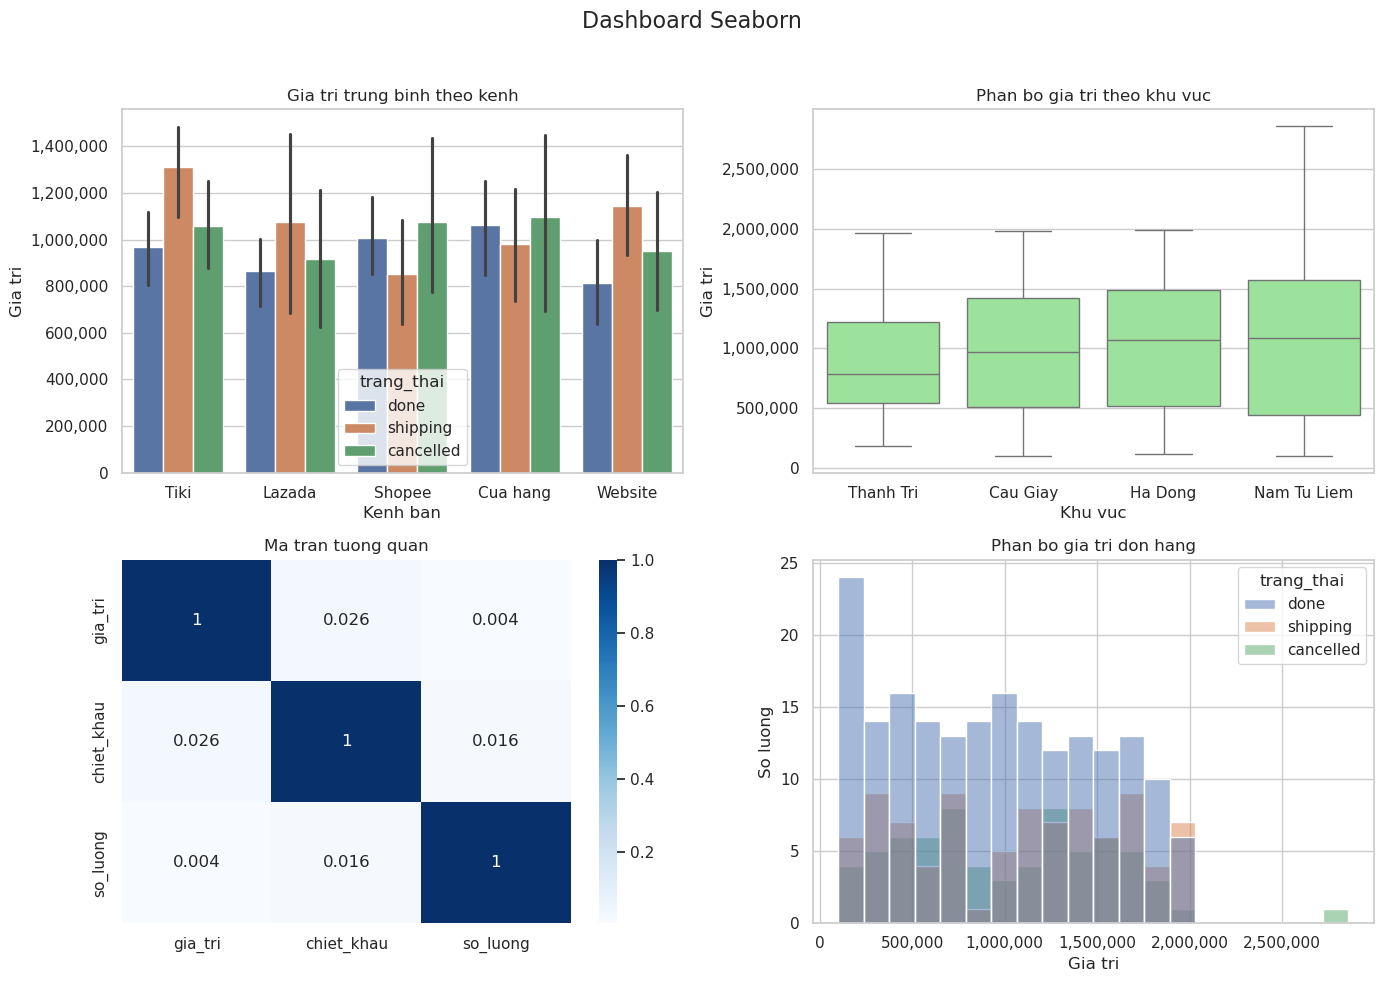


Da luu file dashboard_seaborn.png


In [14]:
# PHAN 4.2
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter
print("Dang ve dashboard seaborn...")
print()
# Cai dat theme
sns.set_theme(style="whitegrid")
# Tao figure
fig = plt.figure(figsize=(14,10))
# Chia thanh 2 hang 2 cot
grid = fig.add_gridspec(2,2)
# BIEU DO 1 - BARPLOT
ax1 = fig.add_subplot(grid[0,0])
sns.barplot(data=df_clean,x="kenh_ban",y="gia_tri",hue="trang_thai",errorbar=("ci",95),ax=ax1)
ax1.set_title("Gia tri trung binh theo kenh")
ax1.set_xlabel("Kenh ban")
ax1.set_ylabel("Gia tri")
ax1.yaxis.set_major_formatter(FuncFormatter(lambda x,pos: format(int(x),",")))
# BIEU DO 2 - BOXPLOT
ax2 = fig.add_subplot(grid[0,1])
sns.boxplot(data=df_clean,x="khu_vuc",y="gia_tri",color="lightgreen",ax=ax2)
ax2.set_title("Phan bo gia tri theo khu vuc")
ax2.set_xlabel("Khu vuc")
ax2.set_ylabel("Gia tri")
ax2.yaxis.set_major_formatter(FuncFormatter(lambda x,pos: format(int(x),",")))
# BIEU DO 3 - HEATMAP
ax3 = fig.add_subplot(grid[1,0])
bang_corr = df_clean[["gia_tri","chiet_khau","so_luong"]].corr()
sns.heatmap(bang_corr,annot=True,cmap="Blues",ax=ax3)
ax3.set_title("Ma tran tuong quan")
# BIEU DO 4 - HISTPLOT
ax4 = fig.add_subplot(grid[1,1])
sns.histplot(data=df_clean,x="gia_tri",hue="trang_thai",bins=20,ax=ax4)
ax4.set_title("Phan bo gia tri don hang")
ax4.set_xlabel("Gia tri")
ax4.set_ylabel("So luong")
ax4.xaxis.set_major_formatter(FuncFormatter(lambda x,pos: format(int(x),",")))
# Tieu de chung
fig.suptitle("Dashboard Seaborn",fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
# Luu anh
plt.savefig("dashboard_seaborn.png",dpi=200)
plt.show()
print()
print("Da luu file dashboard_seaborn.png")